# Impact of the alpha-fairness parameter on Test Accuracy

Availability matrices are created by solving the alpha-fairness optimization problem. We vary the parameter alpha between 0.001 and 1.

In [27]:
from plots_utils.loading import ExperimentConfig, load_experiment_results
from plots_utils.plot_av_mat import plot_av_mat
from matplotlib import pyplot as plt
import os
import seaborn as sns
import pandas as pd
import numpy as np

In [28]:
folder='figures/alphaF_exp_beta0.5'
keyword = 'alphaF_exp_beta0'

def fct_refine_res(res):
    res = res[["dataseed", "availability", "test_accuracy", "seed", "lr"]]

    # only look at the final accuracy:
    res.loc[:,['final_acc']] = res['test_accuracy'].apply(lambda x : x[-1])

    # take the best value accross learning rates:
    refined_res = res.groupby(['availability','dataseed', 'seed']).final_acc.apply(np.vstack).to_frame().reset_index()
    refined_res['final_best_acc'] = refined_res['final_acc'].apply(lambda x : x.max())

    refined_res = refined_res[['availability', 'final_best_acc', 'dataseed', 'seed']]

    # regroup all seeds results:
    refined_res = refined_res.groupby(['availability']).final_best_acc.apply(np.vstack).to_frame().reset_index() # regroup seeds results

    # compute the mean and std/3:
    refined_res['mean_acc'] = refined_res['final_best_acc'].apply(lambda x : x.mean())
    refined_res['std_3_acc'] = refined_res['final_best_acc'].apply(lambda x : x.std()/3)

    return(refined_res)

Processing experiments: 100%|██████████| 2/2 [00:02<00:00,  1.41s/it]


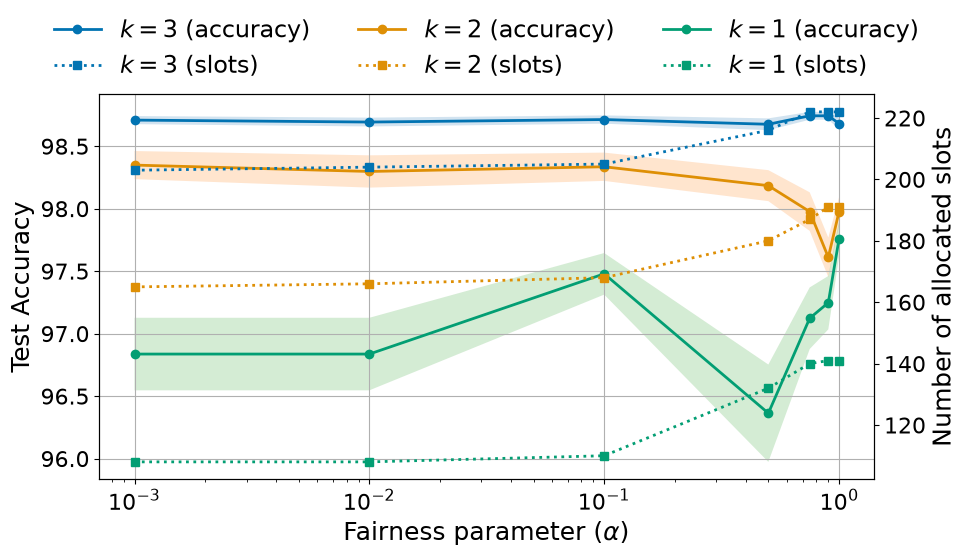

In [29]:
seeds=["42", "78", "84"]

cb_list = ["7cb", "8cb", "10cb"]
# cb_list = ["7cb"]
lrs_list = [["5e-2", "1e-2"], ["5e-2", "1e-2"], ["5e-2", "1e-2"]]
# lab_list = ["$k=3.03$ kgCO2e", "$k=1.98$ kgCO2e", "$k=0.94$ kgCO2e"]
lab_list = ["$k=3$", "$k=2$", "$k=1$"]
# dataseeds=["12345", "12346", "12347"]
dataseeds=["12345", "12346", "12347"]

res_export = {}

plt.figure(figsize=(10, 5))
ax=plt.gca()
ax2 = ax.twinx()

for i in range(len(cb_list)):

    

    cb = cb_list[i]
    lrs = lrs_list[i]
    lab = lab_list[i]
    availabilities = f"alphaF50-alpha0.001-{cb} alphaF50-alpha0.01-{cb} alphaF50-alpha0.1-{cb} alphaF50-alpha0.5-{cb} alphaF50-alpha0.75-{cb} alphaF50-alpha0.9-{cb} alphaF50-alpha1.0-{cb}".split()

    av_av = []
    for av_mat_name in availabilities:
        _path = "../availability_matrices_alphaFvar/av-mat_"+av_mat_name+".csv"
        df = pd.DataFrame(pd.read_csv(_path, index_col=[0]))
        green=df.sum().sum()
        av_av.append(green)

    final_results = pd.DataFrame()

    for ds_idx, ds in enumerate(dataseeds):

        config = ExperimentConfig(
            base_path=os.path.join("..", "logs"),
            experiment="mnist_alphaFVar_beta0.5/dataseed_"+ds,
            seeds=seeds,
            algorithms=["fedavg"],
            events=["global"],
            lr_list=lrs,
            alphas=["0.5"],
            n_clients_list=["7"],
            availabilities=availabilities,
            n_rounds="50",
            participations=["known"],
            biased_list=["2"],
            train_test="train",
        )

        raw_results = load_experiment_results(config)
        raw_results['dataseed'] = ds
        final_results = pd.concat([final_results, raw_results])

    refined_res = fct_refine_res(final_results)
    x_values = [float(a.replace('alphaF50-alpha','').replace(f"-{cb}", '')) for a in refined_res['availability']]
    y = refined_res['mean_acc'] *100
    y_upper = (refined_res['mean_acc']+ refined_res['std_3_acc']) *100
    y_lower =  (refined_res['mean_acc']- refined_res['std_3_acc']) *100
    colorblind_palette = sns.color_palette("colorblind")
    ax.plot(x_values, y, '-o', label = lab+" (accuracy)", color=colorblind_palette[i % len(colorblind_palette)], markersize=6, linewidth=2)
    ax.fill_between(x_values, y_upper, y_lower, alpha=0.2)

    
    ax2.plot(x_values, av_av, ':s', label=lab + " (slots)", color=colorblind_palette[i % len(colorblind_palette)], markersize=6, linewidth=2)

    res_export[str(lab_list[i])] = {"alpha":x_values, "slots":[int(val) for val in av_av], "mean_acc":list(refined_res["mean_acc"]), "std_3_acc":list(refined_res["std_3_acc"])}


ax.grid()
plt.xlabel("Fairness parameter ($\\alpha$)", fontsize=18)
ax.set_ylabel("Test Accuracy", fontsize=18)
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)
ax2.tick_params(axis='y', labelsize=16)
ax.set_xscale('log')
ax.set_xlabel("Fairness parameter ($\\alpha$)", fontsize=18)
ax2.set_ylabel("Number of allocated slots", fontsize=18)


# Combine legends
# UNCOMMENT LATER!!!
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
tot_lines = [lines[0], lines2[0], lines[1], lines2[1], lines[2], lines2[2]]
tot_labels = [labels[0], labels2[0], labels[1], labels2[1], labels[2], labels2[2]]
ax2.legend(tot_lines, tot_labels, fontsize=17, bbox_to_anchor=(0.5, 1.25), ncol=3, loc='upper center', frameon=False)


# plt.show()
plt.savefig(folder+f"/alphaF_var-allcb.png", bbox_inches='tight', dpi=300)

In [32]:
res_export

{'$k=3$': {'alpha': [0.001, 0.01, 0.1, 0.5, 0.75, 0.9, 1.0],
  'slots': [203, 204, 205, 216, 222, 222, 222],
  'mean_acc': [0.9870888988176981,
   0.9869333373175727,
   0.9871333241462708,
   0.986755543284946,
   0.9874333341916403,
   0.9874333341916403,
   0.9868111146820916],
  'std_3_acc': [0.00032487364447342454,
   0.0003520626960307237,
   0.0003314722630723147,
   0.0004724784130792825,
   0.0003138778081383518,
   0.0003138778081383518,
   0.00043388979345870203]},
 '$k=2$': {'alpha': [0.001, 0.01, 0.1, 0.5, 0.75, 0.9, 1.0],
  'slots': [165, 166, 168, 180, 187, 191, 191],
  'mean_acc': [0.9834888842370775,
   0.9829777744081285,
   0.9833555685149299,
   0.9818444516923692,
   0.9797666602664523,
   0.976111114025116,
   0.9797666602664523],
  'std_3_acc': [0.001124195415665965,
   0.0012923114911383194,
   0.0011327987639230496,
   0.001239384073016466,
   0.0015430457825747815,
   0.0015777342501808974,
   0.001146223215969454]},
 '$k=1$': {'alpha': [0.001, 0.01, 0.1, 0.5,

In [30]:
# display(refined_res)
display(refined_res)
display(refined_res[["availability","mean_acc"]])
print(list(refined_res["mean_acc"]))
print(x_values)
print([int(val) for val in av_av])

,availability,final_best_acc,mean_acc,std_3_acc
0,alphaF50-alpha0.001-10cb,"[[0.9805999994277954], [0.9805999994277954], [...",0.968367,0.002903
1,alphaF50-alpha0.01-10cb,"[[0.9805999994277954], [0.9805999994277954], [...",0.968367,0.002903
2,alphaF50-alpha0.1-10cb,"[[0.9789000153541565], [0.9821000099182129], [...",0.974789,0.001664
3,alphaF50-alpha0.5-10cb,"[[0.9763000011444092], [0.9763000011444092], [...",0.963633,0.003895
4,alphaF50-alpha0.75-10cb,"[[0.9786999821662903], [0.9817000031471252], [...",0.971233,0.002465
5,alphaF50-alpha0.9-10cb,"[[0.9779000282287598], [0.9796000123023987], [...",0.972478,0.002137
6,alphaF50-alpha1.0-10cb,"[[0.9793999791145325], [0.9835000038146973], [...",0.977589,0.001425


,availability,mean_acc
0,alphaF50-alpha0.001-10cb,0.968367
1,alphaF50-alpha0.01-10cb,0.968367
2,alphaF50-alpha0.1-10cb,0.974789
3,alphaF50-alpha0.5-10cb,0.963633
4,alphaF50-alpha0.75-10cb,0.971233
5,alphaF50-alpha0.9-10cb,0.972478
6,alphaF50-alpha1.0-10cb,0.977589


[0.9683666626612345, 0.9683666626612345, 0.9747888843218485, 0.9636333253648546, 0.9712333281834921, 0.9724777804480659, 0.9775888919830322]
[0.001, 0.01, 0.1, 0.5, 0.75, 0.9, 1.0]
[108, 108, 110, 132, 140, 141, 141]


## Av mat

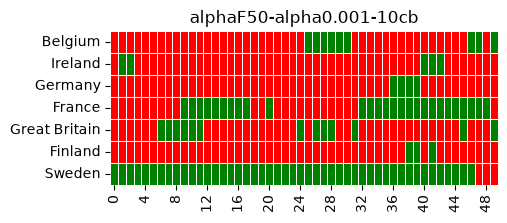

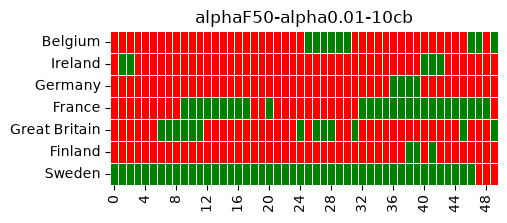

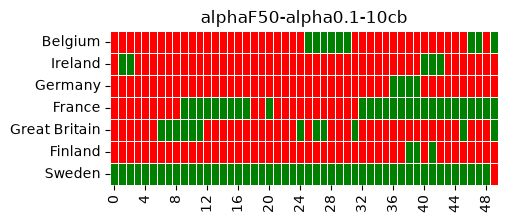

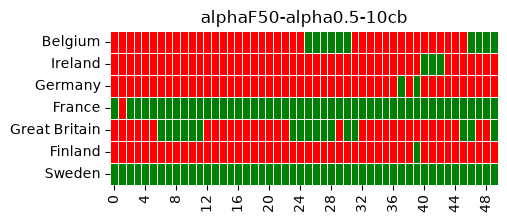

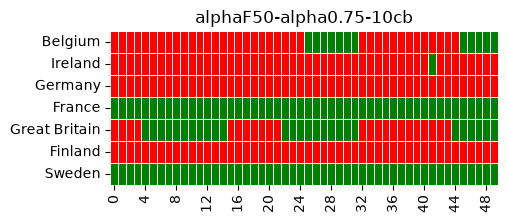

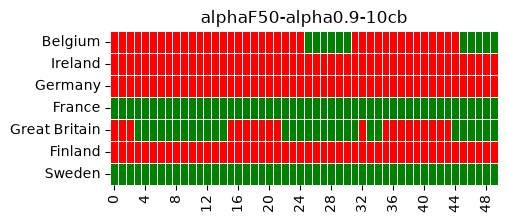

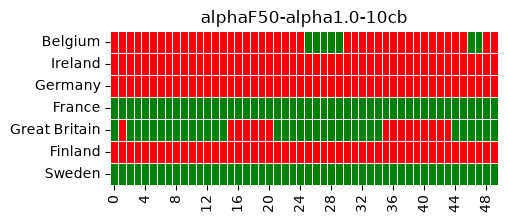

In [31]:
cb="10cb"
av_mat_list = f"alphaF50-alpha0.001-{cb} alphaF50-alpha0.01-{cb} alphaF50-alpha0.1-{cb} alphaF50-alpha0.5-{cb} alphaF50-alpha0.75-{cb} alphaF50-alpha0.9-{cb} alphaF50-alpha1.0-{cb}".split()
folder='alphaF_exp/av-mat'
for av_mat_name in av_mat_list:
    plot_av_mat(av_mat_name, folder)